<!--- sf-header --->
<table align="left">
<tr>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/colab/import/https%3A%2F%2Fraw.githubusercontent.com%2Fstatmike%2Fscale-forecasting%2Fmain%2Fnotebooks%2F09_custom_models_and_metrics.ipynb">
      <img width="32px" src="https://lh3.googleusercontent.com/JmcxdQi-qOpctIvWKgPtrzZdJJK-J3sWE1RsfjZNwshCFgE_9fULcNpuXYTilIR2hjwN" alt="Colab Enterprise logo">
      <br>Run in<br>Colab Enterprise
    </a>
  </td>
</tr>
</table>
<br clear="left"/>

> **Run in Colab Enterprise:** click the badge to import this notebook, pick a runtime, and
> **Run all**. The Terraform-deployed templates already carry the `SF_*` run identity in their env,
> so there's no environment cell to fill in. Runs on the **`sf-main`** runtime template (Python 3.11) — or fully locally with just a clone; this notebook needs no cloud at all. See
> [`docs/notebook_runtimes.md`](https://github.com/statmike/scale-forecasting/blob/main/docs/notebook_runtimes.md)
> for the per-notebook template mapping and the headless acceptance harness.


# 09 · Extending the Platform: Authoring Custom 1-File Models & Custom Metrics

`scale-forecasting` is designed around a **strict 1-file plugin architecture** (`models/base_model.py` and `metrics/base_metric.py`). Adding a proprietary forecasting algorithm or a domain-specific evaluation metric requires **zero edits to any engine, worker, backtester, calibrator, or ensembler** — and ships dynamically to Spark, Ray, Vertex AI, and GCE workers via the `src/` archive with **zero container image rebuilds**!

```mermaid
flowchart LR
    subgraph Plugins["1-File Plugin Contracts"]
        M["Custom Model (BaseModel)<br/>models/<name>.py + @register"]
        E["Custom Metric (BaseMetric)<br/>metrics/<name>.py + @register"]
    end
    subgraph Auto["Automatic Framework Integration (Zero Engine Edits)"]
        A1["Rolling-Origin Backtest & Conformal Intervals"]
        A2["Optuna HPO & 6 Ensemble Strategies"]
        A3["7 FPP3 Hierarchical Reconciliation Methods"]
        A4["Zero-Rebuild Dynamic src.zip Code Shipping"]
    end
    M & E --> A1 & A2 & A3 & A4
```

## Act 1 · Cloud Bootstrap & Deployment Resolution

On a managed cloud notebook (**Colab Enterprise**, **Vertex AI Workbench**) the bootstrap cell below clones or updates the repository and installs the locked dependency set (`uv.lock`) into an isolated `.colab-deps` prefix so `import scale_forecasting` resolves against the exact package versions every cloud worker uses. **In a local clone with `.venv`, this cell is a fast no-op.**

In [1]:
# Cloud bootstrap: clone + install the LOCKED dependency set (uv.lock) so
# `import scale_forecasting` resolves against the exact versions every other surface runs.
import importlib.util
import os
import shutil
import subprocess
import sys

REPO_URL = os.environ.get("SF_REPO_URL", "https://github.com/statmike/scale-forecasting.git")
REPO_DIR = os.environ.get("SF_REPO_DIR", "scale-forecasting")
EXTRAS = []

if importlib.util.find_spec("scale_forecasting") is None:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    uv = shutil.which("uv")
    if uv is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv"], check=True)
        uv = shutil.which("uv") or "uv"
    reqs = os.path.abspath(os.path.join(REPO_DIR, "colab-requirements.txt"))
    extra_flags = [f for e in EXTRAS for f in ("--extra", e)]
    subprocess.run(
        [uv, "export", "--frozen", "--no-emit-project", "--no-hashes", "--no-dev", *extra_flags, "-o", reqs],
        cwd=REPO_DIR,
        check=True,
    )
    target = os.path.abspath(os.path.join(REPO_DIR, ".colab-deps"))
    subprocess.run(
        [uv, "pip", "install", "--python", sys.executable, "--target", target, "-r", reqs],
        check=True,
    )
    sys.path.insert(0, target)
    sys.path.insert(0, os.path.join(REPO_DIR, "src"))
    print("installed scale_forecasting from", REPO_DIR)
else:
    print("scale_forecasting already importable — skipping bootstrap")

scale_forecasting already importable — skipping bootstrap


## Act 1 · Author & Register a Custom `BaseModel` Subclass

Every model in `src/scale_forecasting/models/` inherits from `BaseModel`, sets its metadata class attributes, implements `fit(self, y: pd.Series, X: pd.DataFrame | None = None)` and `predict(self, horizon: int, X: pd.DataFrame | None = None, quantiles=DEFAULT_QUANTILES)` (plus optional `fit_panel` / `predict_panel` for cross-series global/hybrid mode), and decorates with `@register`.

Below we build **`damped_seasonal_blend`** — a custom model that blends a seasonal naive lag with a damped linear drift trend — and register it directly into the live model factory.

In [2]:
from typing import ClassVar
import numpy as np
import pandas as pd
from scale_forecasting import model_catalog
from scale_forecasting.features import invert_transform
from scale_forecasting.models.base_model import DEFAULT_QUANTILES, BaseModel, Family, Runtime, register

@register
class DampedSeasonalBlendModel(BaseModel):
    """Custom 1-file model blending seasonal lag repetition with a damped drift trend."""

    name: ClassVar[str] = "damped_seasonal_blend"
    family: ClassVar[Family] = "statistical"
    runtime: ClassVar[Runtime] = "python"
    package: ClassVar[str] = "numpy"
    package_url: ClassVar[str] = "https://numpy.org/"
    supports_exog: ClassVar[bool] = False
    supports_native_intervals: ClassVar[bool] = False

    def fit(self, y: pd.Series, X: pd.DataFrame | None = None) -> None:
        vals = y.astype(float).to_numpy()
        self._damping = float(self.params.get("damping", 0.85))
        self._seasonal_weight = float(self.params.get("seasonal_weight", 0.7))
        period = min(int(self.params.get("period", 7)), len(vals))
        self._last_season = vals[-period:].copy()
        self._last_val = float(vals[-1])
        self._slope = float(vals[-1] - vals[max(0, len(vals) - 28)]) / max(1, min(28, len(vals) - 1))
        self._last_date = y.index[-1]
        seasonal_in = np.resize(self._last_season, len(vals))
        drift_in = vals[0] + self._slope * np.arange(len(vals))
        fitted = self._seasonal_weight * seasonal_in + (1.0 - self._seasonal_weight) * drift_in
        self._set_residuals(vals - fitted)

    def predict(
        self,
        horizon: int,
        X: pd.DataFrame | None = None,
        quantiles: tuple[float, ...] = DEFAULT_QUANTILES,
    ) -> pd.DataFrame:
        steps = self._forecast_steps(horizon)
        idx = np.arange(1, steps + 1, dtype=float)
        damped_steps = np.cumsum(self._damping ** idx)
        drift_part = self._last_val + self._slope * damped_steps
        seasonal_part = np.resize(self._last_season, steps)
        mean = (self._seasonal_weight * seasonal_part + (1.0 - self._seasonal_weight) * drift_part)[-horizon:]
        qmap_t = self.residual_intervals(mean, quantiles)
        t, lam = self.ctx.transform, self.ctx.transform_lambda
        qmap = {q: invert_transform(v, t, lam) for q, v in qmap_t.items()}
        ds = self._forecast_index(horizon)
        return self._assemble_frame(ds, qmap, raw=invert_transform(mean, t, lam))

cat = model_catalog()
display(cat[cat["model"] == "damped_seasonal_blend"])

,model,family,runtime,package,package_url,available,local,spark,ray,gpu,vertex_automl,bigquery,exog,future_covariates,past_covariates,static_covariates,explainability,global_mode,hybrid_mode
17,damped_seasonal_blend,statistical,python,numpy,https://numpy.org/,True,True,True,True,False,False,False,False,False,False,False,False,False,False


## Act 2 · Test the Custom Model in `run_model()` & `bakeoff()`

Because `damped_seasonal_blend` is now registered in `models._REGISTRY`, it works immediately with rolling-origin backtesting, conformal interval calibration, and stacked ensembles in `bakeoff()`!

model      : damped_seasonal_blend
series     : s_000000  (365 obs)
engine     : spark
status     : ok
forecast   : 28 steps
horizon    : 2022-01-01 → 2022-01-28
metrics    : mae=35.587, rmse=39.265, mse=2146.463, mape=0.272, smape=0.215, wape=0.245, mase=1.379, rmsse=1.295, bias=27.609, coverage=0.714, pinball=9.100, mase_seasonal=2.918, maape=0.241, interval_score=182.009, interval_width=122.217, ope=0.215, rmsle=0.245, msse=2.344, msis=14.866, r2=-0.822, cv=0.267


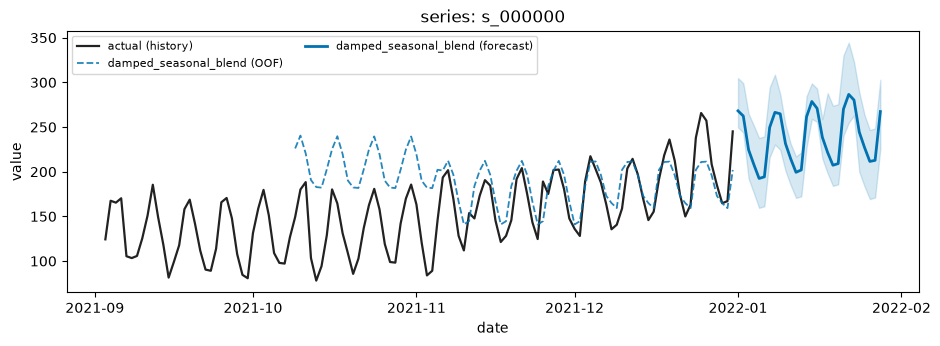

/usr/local/google/home/statmike/Git/scale-forecasting/.venv/lib/python3.11/site-packages/statsmodels/tsa/forecasting/theta.py:44: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  return DeterministicTerm._extend_index(index, steps)


/usr/local/google/home/statmike/Git/scale-forecasting/.venv/lib/python3.11/site-packages/statsmodels/tsa/forecasting/theta.py:44: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  return DeterministicTerm._extend_index(index, steps)


/usr/local/google/home/statmike/Git/scale-forecasting/.venv/lib/python3.11/site-packages/statsmodels/tsa/forecasting/theta.py:44: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  return DeterministicTerm._extend_index(index, steps)


/usr/local/google/home/statmike/Git/scale-forecasting/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/usr/local/google/home/statmike/Git/scale-forecasting/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/usr/local/google/home/statmike/Git/scale-forecasting/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


,model,kind,status,wape,mae,mase,coverage,interval_score
0,ensemble_nnls,ensemble,ok,0.065081,11.581280,0.446160,NaN,NaN
1,ensemble_inverse_error,ensemble,ok,0.082193,14.448024,0.556509,NaN,NaN
2,holtwinters,base,ok,0.094653,16.327272,0.628736,0.446429,97.067969
3,damped_seasonal_blend,base,ok,0.098754,17.351532,0.668343,1.000000,130.974301
4,xgboost,base,ok,0.149634,26.234712,1.010474,0.000000,257.909207
5,theta,base,ok,0.167225,29.033085,1.118113,0.982143,302.470150


__main__.DampedSeasonalBlendModel

In [3]:
import matplotlib.pyplot as plt
from scale_forecasting import build_predictions_frame, plot_forecasts_frame
from scale_forecasting.models import _REGISTRY as _MODEL_REGISTRY
from scale_forecasting.playground import bakeoff, run_model, sample_data, summarize

panel = sample_data(n_series=3, history=365, freq="D")
custom_run = run_model("damped_seasonal_blend", data=panel, ts_id="s_000000", horizon=28, backtest=True)
print(summarize(custom_run))

pred_rows = (
    custom_run.result.predictions.rename(columns={"ds": "forecast_date"})
    .assign(ts_id=custom_run.result.ts_id, model_type=custom_run.result.model_type)
    .to_dict("records")
)
oof_rows = (
    custom_run.result.oof.rename(columns={"ds": "forecast_date"})
    .assign(ts_id=custom_run.result.ts_id, model_type=custom_run.result.model_type)
    .to_dict("records")
)
hist_rows = custom_run.series[["ts_id", "ds", "y"]].to_dict("records")
pf = build_predictions_frame(pred_rows, oof_rows=oof_rows, history_rows=hist_rows)
plot_forecasts_frame(pf, history_tail=120)
plt.show()

bo = bakeoff(
    data=panel,
    ts_id="s_000000",
    models=["damped_seasonal_blend", "theta", "holtwinters", "xgboost"],
    horizon=28,
    n_folds=2,
)
display(bo.leaderboard[["model", "kind", "status", "wape", "mae", "mase", "coverage", "interval_score"]])

# Clean up temporary in-memory registration so canonical 34-model inventory stays unchanged
_MODEL_REGISTRY.pop("damped_seasonal_blend", None)

## Act 3 · Author & Test a Custom `BaseMetric` Subclass

Every metric in `src/scale_forecasting/metrics/` inherits from `BaseMetric`, declares `name` and `direction` (`'lower'`, `'higher'`, or `'zero'`), and implements `compute(self, ctx: MetricContext) -> float`.

Below we write **`mdae` (Median Absolute Error)** — a robust point accuracy metric insensitive to extreme outliers — and inspect the automatic BigQuery schema migration (`registry.ddl.render_migrations`) that adds a new metric column to `forecast_metadata` and `v_model_leaderboard`.

In [4]:
from scale_forecasting.metrics.base_metric import BaseMetric, MetricContext, MetricDirection
from scale_forecasting.registry.ddl import render_migrations

class MedianAbsoluteErrorMetric(BaseMetric):
    """Robust Median Absolute Error: median(|yhat - y_true|)."""

    name: ClassVar[str] = "mdae"
    direction: ClassVar[MetricDirection] = "lower"

    def compute(self, ctx: MetricContext) -> float:
        if ctx.abs_err.size == 0:
            return float("nan")
        return float(np.median(ctx.abs_err))

ctx = MetricContext.from_arrays(
    y_true=np.array([100.0, 110.0, 105.0, 500.0]),  # note the 500.0 outlier
    yhat=np.array([102.0, 108.0, 107.0, 115.0]),
)
print(f"Standard MAE (skewed by outlier): {ctx.value('mae'):.2f}")
print(f"Custom MdAE (robust median):      {MedianAbsoluteErrorMetric().compute(ctx):.2f}")

print("\n--- Automatic BigQuery Schema Migration DDL (registry.ddl.render_migrations) ---")
ddl_stmt = render_migrations("my_project.scale_forecasting")["forecast_metadata"]
print("\n".join(ddl_stmt.splitlines()[:8]))

Standard MAE (skewed by outlier): 97.75
Custom MdAE (robust median):      2.00

--- Automatic BigQuery Schema Migration DDL (registry.ddl.render_migrations) ---
ALTER TABLE `my_project.scale_forecasting.forecast_metadata`
  ADD COLUMN IF NOT EXISTS ensemble_id STRING,
  ADD COLUMN IF NOT EXISTS fold_id INT64,
  ADD COLUMN IF NOT EXISTS mae FLOAT64,
  ADD COLUMN IF NOT EXISTS rmse FLOAT64,
  ADD COLUMN IF NOT EXISTS mse FLOAT64,
  ADD COLUMN IF NOT EXISTS mape FLOAT64,
  ADD COLUMN IF NOT EXISTS smape FLOAT64,
